<a href="https://colab.research.google.com/github/5ahar-K/IIB-project-media/blob/main/Optimsation%20over%20Na.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import erfc, kv, gamma
from scipy.integrate import cumulative_trapezoid
import math


def Q(x):
    return 0.5 * erfc(x / np.sqrt(2.0))


def compute_link_params(lam, Z, Cn2, w0, fc, ra, wa):
    kf    = 2 * np.pi / lam
    rho_Z = (0.55 * Cn2 * kf**2 * Z)**(-3/5)
    Theta = 1 + 2 * w0**2 / rho_Z**2
    wz    = w0 * np.sqrt(1 + Theta * (lam * Z / (np.pi * w0**2))**2)
    eta   = 1 - np.exp(-2 * ra**2 / wz**2)
    sigma_I = 8 * wa
    delta   = sigma_I * fc / ra
    fc_eff  = fc + delta
    print("=" * 55)
    print("LINK PARAMETER SUMMARY")
    print("=" * 55)
    print(f"  wz                = {wz*100:.4f} cm")
    print(f"  Regime            = {'Gaussian (wz<ra)' if wz < ra else 'Airy (wz>ra)'}")
    print(f"  eta               = {eta*100:.6f} %  ({10*np.log10(max(eta,1e-30)):.2f} dB)")
    print(f"  delta (defocus)   = {delta*1e3:.4f} mm")
    print(f"  fc                = {fc*1e3:.2f} mm")
    print(f"  fc_eff = fc+delta = {fc_eff*1e3:.4f} mm  (used in simulation)")
    print(f"  delta/fc          = {delta/fc*100:.2f} %")
    print(f"  sigma_I           = {sigma_I*1e3:.4f} mm ")
    print(f"  sigma_I/wa        = {sigma_I/wa:.4f} ")
    print("=" * 55)
    print()
    return {"wz": wz, "eta": eta, "sigma_I": sigma_I, "delta": delta, "fc_eff": fc_eff}


def malaga_pdf(h, alpha, beta, g, Omega):
    h = np.asarray(h, dtype=float)
    h = np.maximum(h, 1e-300)
    AM = (2 * alpha**(alpha/2.0) / (g**(1 + alpha/2.0) * gamma(alpha))) * \
         ((g * beta / (g * beta + Omega))**(beta + alpha/2.0))
    beta_int = int(beta)
    if beta_int != beta:
        raise ValueError("beta must be an integer.")
    out = np.zeros_like(h)
    for m in range(1, beta_int + 1):
        am = (math.comb(beta_int - 1, m - 1) *
              (g * beta + Omega)**(1 - m/2.0) / math.factorial(m - 1) *
              (Omega / g)**(m - 1) *
              (alpha / beta)**(m/2.0))
        nu  = alpha - m
        arg = 2.0 * np.sqrt(alpha * beta * h / (g * beta + Omega))
        out += am * (h**((alpha + m)/2.0 - 1.0)) * kv(nu, arg)
    return AM * out


def build_malaga_cdf(alpha, beta, g, Omega, h_max=50.0, grid_n=200_000):
    h_grid    = np.linspace(0.0, h_max, grid_n)
    h_grid[0] = 1e-12
    pdf       = malaga_pdf(h_grid, alpha, beta, g, Omega)
    cdf       = cumulative_trapezoid(pdf, h_grid, initial=0.0)
    cdf      /= cdf[-1]
    return h_grid, cdf


def sample_malaga_batch(h_grid, cdf, size, rng):
    return np.interp(rng.random(size), cdf, h_grid)


def sample_h1_batch(Z, zeta1, h_grid, cdf, size, rng):
    return np.exp(-zeta1 * Z) * sample_malaga_batch(h_grid, cdf, size, rng)


def compute_h2_batch(theta_x, theta_y, Na, wa, wf, fc_eff, sigma_I):
    """Spot centre x0 = fc_eff * theta (exact defocused ray trace)."""
    w_prime  = wa + wf
    x0       = fc_eff * theta_x
    y0       = fc_eff * theta_y
    i        = np.arange(Na)
    j        = np.arange(Na)
    x_left   = (i - 1 - Na/2) * w_prime + wf/2
    x_right  = (i     - Na/2) * w_prime - wf/2
    ax1      = (x_left[None, :]  - x0[:, None]) / sigma_I
    ax2      = (x_right[None, :] - x0[:, None]) / sigma_I
    px       = Q(ax1) - Q(ax2)
    y_bottom = (j - 1 - Na/2) * w_prime + wf/2
    y_top    = (j     - Na/2) * w_prime - wf/2
    ay1      = (y_bottom[None, :] - y0[:, None]) / sigma_I
    ay2      = (y_top[None, :]    - y0[:, None]) / sigma_I
    py       = Q(ay1) - Q(ay2)
    h2       = px[:, :, None] * py[:, None, :]
    s        = np.sum(h2, axis=(1, 2), keepdims=True)
    positive = (s > 0).squeeze()
    if np.any(positive):
        h2[positive] /= s[positive]
    return h2


def interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff):
    """Beam centre outside array — uses fc_eff for accurate position."""
    w_prime = wa + wf
    r_array = (Na * w_prime) / 2.0
    r_d     = np.sqrt((fc_eff * theta_x)**2 + (fc_eff * theta_y)**2)
    return r_d > r_array


def snr_mask(h1, Pt, mu, sigma_s, sigma0, eta, gamma_th_dB=5.0):
    """SNR below threshold — total power = eta * Pt * h1 (h2 sums to 1)."""
    gamma_th = 10 ** (gamma_th_dB / 10.0)
    P_rx     = eta * Pt * h1
    gamma    = (mu * P_rx)**2 / (sigma_s**2 * P_rx + sigma0**2)
    return gamma < gamma_th


def generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0, rng, eta=1.0, p1=0.5):
    B, Na, _ = h2.shape
    s      = (rng.random((B, L)) < p1).astype(float)
    h_full = h1[:, None, None] * h2
    s4     = s[:, None, None, :]
    h4     = h_full[:, :, :, None]
    Pt_rx  = eta * Pt
    mean   = mu * Pt_rx * h4 * s4
    var    = (sigma_s**2) * (Pt_rx * h4 * s4) + sigma0**2
    R      = rng.normal(mean, np.sqrt(var))
    return s, R


def joint_track_h_hat_batch(R, mu):
    B, Na, _, L = R.shape
    y        = np.sum(R, axis=(1, 2))
    order    = np.argsort(-y, axis=1)
    order4   = order[:, None, None, :]
    R_sorted = np.take_along_axis(R, order4, axis=3)
    cumsum_R = np.cumsum(R_sorted, axis=3)
    sumsq    = np.sum(cumsum_R**2, axis=(1, 2))
    m        = np.arange(1, L+1)[None, :]
    metric   = sumsq / m
    best_m   = np.argmax(metric, axis=1) + 1
    k            = np.arange(L)[None, :]
    s_hat_sorted = (k < best_m[:, None]).astype(float)
    s4           = s_hat_sorted[:, None, None, :]
    R_weighted   = R_sorted * s4
    h_hat        = np.sum(R_weighted, axis=3) / (best_m[:, None, None] * mu)
    return h_hat


def estimate_beam_centre_batch(h_hat, Na, wa, wf):
    """Returns x_hat, y_hat (B,) in detector-plane metres."""
    w_prime = wa + wf
    B       = h_hat.shape[0]
    x_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    y_c     = (np.arange(Na) - (Na - 1) / 2.0) * w_prime
    h_pos   = np.maximum(h_hat, 0.0)
    total   = np.sum(h_pos, axis=(1, 2))
    hx      = np.sum(h_pos, axis=2)
    hy      = np.sum(h_pos, axis=1)
    safe    = total > 0
    x_hat   = np.zeros(B)
    y_hat   = np.zeros(B)
    x_hat[safe] = np.sum(hx[safe] * x_c[None, :], axis=1) / total[safe]
    y_hat[safe] = np.sum(hy[safe] * y_c[None, :], axis=1) / total[safe]
    return x_hat, y_hat


def rmse_for_Pt(Pt, params, h1_cdf, n_trials, rng,
                batch_size=5000, interrupted_penalty=None):
    Na          = params["Na"]
    wa          = params["wa"]
    wf          = params["wf"]
    fc_eff      = params["fc_eff"]
    sigma_I     = params["sigma_I"]
    L           = params["L"]
    mu          = params["mu"]
    sigma_s     = params["sigma_s"]
    sigma0      = params["sigma0"]
    eta         = params.get("eta", 1.0)
    Z           = params["Z"]
    zeta1       = params["zeta1"]
    gamma_th_dB = params.get("gamma_th_dB", 5.0)

    h_grid, cdf = h1_cdf
    sq_err_sum  = 0.0
    n_valid     = 0
    n_int_geom  = 0
    n_int_snr   = 0

    done = 0
    while done < n_trials:
        B = min(batch_size, n_trials - done)

        theta_x = rng.normal(0.0, params["sigma_x"], size=B)
        theta_y = rng.normal(0.0, params["sigma_y"], size=B)

        x_true = fc_eff * theta_x
        y_true = fc_eff * theta_y

        geom_int    = interruption_mask(theta_x, theta_y, Na, wa, wf, fc_eff)
        n_int_geom += int(np.sum(geom_int))

        h1_all   = sample_h1_batch(Z, zeta1, h_grid, cdf, size=B, rng=rng)

        snr_int  = np.zeros(B, dtype=bool)
        non_geom = ~geom_int
        if np.any(non_geom):
            snr_int[non_geom] = snr_mask(
                h1_all[non_geom], Pt, mu, sigma_s, sigma0, eta, gamma_th_dB
            )
        n_int_snr  += int(np.sum(snr_int))

        interrupted  = geom_int | snr_int
        n_int_batch  = int(np.sum(interrupted))

        if interrupted_penalty is not None:
            sq_err_sum += n_int_batch * (interrupted_penalty ** 2)
            n_valid    += n_int_batch

        keep = ~interrupted
        if np.any(keep):
            B2 = int(np.sum(keep))
            tx = theta_x[keep]
            ty = theta_y[keep]
            xt = x_true[keep]
            yt = y_true[keep]
            h1 = h1_all[keep]

            h2    = compute_h2_batch(tx, ty, Na, wa, wf, fc_eff, sigma_I)
            _, R  = generate_R_batch(Pt, h1, h2, L, mu, sigma_s, sigma0,
                                     rng, eta=eta)
            h_hat = joint_track_h_hat_batch(R, mu)
            x_hat, y_hat = estimate_beam_centre_batch(h_hat, Na, wa, wf)

            sq_err_sum += np.sum((x_hat - xt)**2 + (y_hat - yt)**2)
            n_valid    += B2

        done += B

    rmse          = np.sqrt(sq_err_sum / n_valid) if n_valid > 0 else np.nan
    int_frac      = (n_int_geom + n_int_snr) / n_trials
    int_frac_geom = n_int_geom / n_trials
    int_frac_snr  = n_int_snr  / n_trials
    return rmse, int_frac, int_frac_geom, int_frac_snr


def joint_optimise(D, Na_list, ratio_list, base_params, h1_cdf,
                   Pt_dBm, n_trials=40_000, seed=2025, batch_size=10_000):
    """
    Joint (Na, sigma_I/wa) optimisation under constant aperture D.

      D          : fixed total array side length [m] (wa = D / Na, NOT free)
      Na_list    : array sizes to try
      ratio_list : sigma_I / wa values to try
      Pt_dBm     : single transmit power (pick one where link is closed)

    fc_eff is recomputed per cell because sigma_I (hence defocus) changes.
    Returns (grid, best) where grid[a,b] is RMSE in um.
    """
    rng = np.random.default_rng(seed)
    Pt  = 10 ** ((Pt_dBm - 30) / 10.0)
    fc  = base_params["_fc"]
    ra  = base_params["_ra"]

    grid = np.full((len(Na_list), len(ratio_list)), np.nan)
    best = {"rmse": np.inf}

    for a, Na in enumerate(Na_list):
        wa = D / Na                                  # constant-aperture
        for b, r in enumerate(ratio_list):
            sigma_I = r * wa
            p = base_params.copy()
            p["Na"]      = Na
            p["wa"]      = wa
            p["sigma_I"] = sigma_I
            p["fc_eff"]  = fc + sigma_I * fc / ra     # defocus per cell
            p["L"]       = base_params["L"]

            rmse, intf, ig, isn = rmse_for_Pt(
                Pt, p, h1_cdf, n_trials, rng, batch_size=batch_size)
            rmse_um = rmse * 1e6
            grid[a, b] = rmse_um
            print(f"  Na={Na:3d}  wa={wa*1e6:7.1f}um  "
                  f"sI/wa={r:5.2f}  RMSE={rmse_um:8.2f}um  "
                  f"Pint={intf:.3f} (g={ig:.3f},s={isn:.3f})")

            if rmse_um < best["rmse"]:
                best = {"rmse": rmse_um, "Na": Na, "wa": wa,
                        "ratio": r, "sigma_I": sigma_I,
                        "fc_eff": p["fc_eff"], "Pint": intf}

    print("\n" + "=" * 55)
    print("JOINT OPTIMUM")
    print("=" * 55)
    print(f"  Na          = {best['Na']}")
    print(f"  wa          = {best['wa']*1e6:.1f} um")
    print(f"  sigma_I/wa  = {best['ratio']:.2f}")
    print(f"  sigma_I     = {best['sigma_I']*1e6:.1f} um")
    print(f"  fc_eff      = {best['fc_eff']*1e3:.4f} mm")
    print(f"  RMSE        = {best['rmse']:.2f} um")
    print(f"  P_int       = {best['Pint']:.4f}")
    print("=" * 55)
    return grid, best


def plot_joint_grid(grid, Na_list, ratio_list, best):
    fig, ax = plt.subplots(figsize=(7, 5))
    im = ax.imshow(grid, origin="lower", aspect="auto", cmap="viridis_r")
    ax.set_xticks(range(len(ratio_list)))
    ax.set_xticklabels([f"{r:g}" for r in ratio_list])
    ax.set_yticks(range(len(Na_list)))
    ax.set_yticklabels([f"{Na}" for Na in Na_list])
    ax.set_xlabel(r"$\sigma_I/w_a$")
    ax.set_ylabel(r"$N_a$ (array side)")
    ax.set_title("Joint RMSE grid (um) - constant aperture")
    bi = Na_list.index(best["Na"])
    bj = ratio_list.index(best["ratio"])
    ax.scatter([bj], [bi], s=200, facecolors="none",
               edgecolors="r", linewidths=2)
    for a in range(len(Na_list)):
        for b in range(len(ratio_list)):
            ax.text(b, a, f"{grid[a,b]:.0f}", ha="center",
                    va="center", color="w", fontsize=7)
    fig.colorbar(im, label="RMSE (um)")
    plt.tight_layout()
    plt.show()


def make_power_sweep(Pt_dB_min=-55, Pt_dB_max=-10, n_points=20):
    Pt_dB_list  = np.linspace(Pt_dB_min, Pt_dB_max, n_points)
    Pt_list     = 10 ** (Pt_dB_list / 10.0)
    Pt_dBm_list = Pt_dB_list + 30
    return Pt_list, Pt_dBm_list


if __name__ == "__main__":
    lam = 1550e-9; Z = 250; Cn2 = 1.7e-13; w0 = 0.03
    fc  = 0.05;   ra = 0.05; Na = 4; wa = 250e-6   # baseline pixel 250 um

    rho = 0.596; Omega_prime = 1.3265; b0 = 0.1079
    g = 2 * b0 * (1 - rho); Omega = Omega_prime
    alpha = 2.296; beta = 2
    zeta1 = 0.43e-3

    link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa)

    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.\n")



LINK PARAMETER SUMMARY
  wz                = 3.0908 cm
  Regime            = Gaussian (wz<ra)
  eta               = 99.466677 %  (-0.02 dB)
  delta (defocus)   = 2.0000 mm
  fc                = 50.00 mm
  fc_eff = fc+delta = 52.0000 mm  (used in simulation)
  delta/fc          = 4.00 %
  sigma_I           = 2.0000 mm 
  sigma_I/wa        = 8.0000 

Building Malaga CDF... done.



LINK PARAMETER SUMMARY
  wz                = 3.0908 cm
  Regime            = Gaussian (wz<ra)
  eta               = 99.466677 %  (-0.02 dB)
  delta (defocus)   = 2.0000 mm
  fc                = 50.00 mm
  fc_eff = fc+delta = 52.0000 mm  (used in simulation)
  delta/fc          = 4.00 %
  sigma_I           = 2.0000 mm 
  sigma_I/wa        = 8.0000 

Building Malaga CDF... done.

SWEEP  Na   |  sigma_I/wa = 8.00   |  D = 4.00 mm  |  Pt = 20.0 dBm
  Na=  8  wa=  500.0um  sI=4000.0um  RMSE=  287.33um  Pint=0.0000 (geom=0.0000, snr=0.0000)
  Na= 10  wa=  400.0um  sI=3200.0um  RMSE=  273.76um  Pint=0.0000 (geom=0.0000, snr=0.0000)
  Na= 12  wa=  333.3um  sI=2666.7um  RMSE=  259.16um  Pint=0.0001 (geom=0.0000, snr=0.0001)
  Na= 16  wa=  250.0um  sI=2000.0um  RMSE=  231.71um  Pint=0.0000 (geom=0.0000, snr=0.0000)
  Na= 20  wa=  200.0um  sI=1600.0um  RMSE=  206.81um  Pint=0.0000 (geom=0.0000, snr=0.0000)
  Na= 25  wa=  160.0um  sI=1280.0um  RMSE=  179.53um  Pint=0.0001 (geom=0.0000, snr=0.0001)

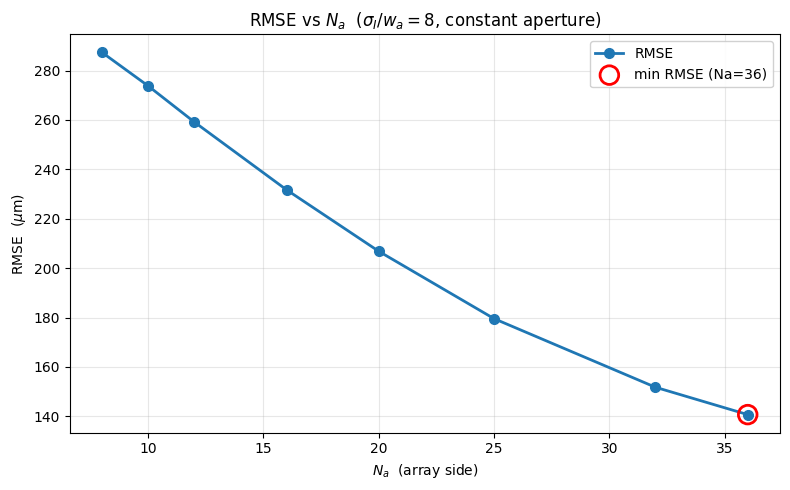

In [ ]:
"""
RMSE and interruption probability vs Na at fixed sigma_I/wa = 0.5.

This reuses every model function from the original simulation file. The only
new piece is a sweep loop over Na (constant aperture D, so wa = D / Na) with
the ratio sigma_I/wa held at 0.5, plus a twin-axis plot.

Drop this in the same folder as your original script (assumed name below) OR
paste the original functions above the marker.
"""

import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------
# Import the model from your original file. Rename the import target
# to match your filename (without .py). If your file is e.g.
# `joint_sim.py`, use:  from joint_sim import (...)
# ------------------------------------------------------------------



def sweep_Na_fixed_ratio(D, Na_list, ratio, base_params, h1_cdf,
                         Pt_dBm, n_trials=40_000, seed=2025,
                         batch_size=10_000):
    """
    Sweep Na with sigma_I/wa = ratio (fixed), constant aperture D.

    For each Na:
      wa       = D / Na                 (constant-aperture constraint)
      sigma_I  = ratio * wa
      fc_eff   = fc + sigma_I * fc / ra (defocus recomputed per cell)

    Returns arrays: rmse_um, p_int, p_int_geom, p_int_snr  (all length len(Na_list))
    """
    rng = np.random.default_rng(seed)
    Pt  = 10 ** ((Pt_dBm - 30) / 10.0)
    fc  = base_params["_fc"]
    ra  = base_params["_ra"]

    rmse_um    = np.full(len(Na_list), np.nan)
    p_int      = np.full(len(Na_list), np.nan)
    p_int_geom = np.full(len(Na_list), np.nan)
    p_int_snr  = np.full(len(Na_list), np.nan)

    print("=" * 70)
    print(f"SWEEP  Na   |  sigma_I/wa = {ratio:.2f}   |  D = {D*1e3:.2f} mm"
          f"  |  Pt = {Pt_dBm:.1f} dBm")
    print("=" * 70)

    for idx, Na in enumerate(Na_list):
        wa      = D / Na                         # constant aperture
        sigma_I = ratio * wa
        p = base_params.copy()
        p["Na"]      = Na
        p["wa"]      = wa
        p["sigma_I"] = sigma_I
        p["fc_eff"]  = fc + sigma_I * fc / ra    # defocus per Na
        p["L"]       = base_params["L"]

        # The received tensor R is (batch, Na, Na, L) -> memory ~ Na^2.
        # Scale the batch down so peak RAM stays roughly constant.
        bs = max(200, int(batch_size * (16 / Na) ** 2))

        rmse, intf, ig, isn = rmse_for_Pt(
            Pt, p, h1_cdf, n_trials, rng, batch_size=bs)

        rmse_um[idx]    = rmse * 1e6
        p_int[idx]      = intf
        p_int_geom[idx] = ig
        p_int_snr[idx]  = isn

        print(f"  Na={Na:3d}  wa={wa*1e6:7.1f}um  sI={sigma_I*1e6:6.1f}um  "
              f"RMSE={rmse_um[idx]:8.2f}um  "
              f"Pint={intf:.4f} (geom={ig:.4f}, snr={isn:.4f})")

    print("=" * 70)
    return rmse_um, p_int, p_int_geom, p_int_snr


def plot_rmse_vs_Na(Na_list, rmse_um, ratio):
    Na_arr = np.asarray(Na_list)

    fig, ax1 = plt.subplots(figsize=(8, 5))

    ax1.plot(Na_arr, rmse_um, "o-", color="tab:blue",
             lw=2, ms=7, label="RMSE")
    ax1.set_xlabel(r"$N_a$  (array side)")
    ax1.set_ylabel(r"RMSE  ($\mu$m)")
    ax1.grid(True, alpha=0.3)

    # mark the RMSE minimum
    i_best = int(np.nanargmin(rmse_um))
    ax1.scatter([Na_arr[i_best]], [rmse_um[i_best]], s=180,
                facecolors="none", edgecolors="red", linewidths=2,
                zorder=5, label=f"min RMSE (Na={Na_arr[i_best]})")

    ax1.set_title(rf"RMSE vs $N_a$  "
                  rf"($\sigma_I/w_a = {ratio:g}$, constant aperture)")
    ax1.legend(loc="upper right", framealpha=0.9)

    fig.tight_layout()
    plt.show()


if __name__ == "__main__":
    # ----- same baseline configuration as the original script -----
    lam = 1550e-9; Z = 250; Cn2 = 1.7e-13; w0 = 0.03
    fc  = 0.05;   ra = 0.05; Na0 = 4; wa0 = 250e-6

    rho = 0.596; Omega_prime = 1.3265; b0 = 0.1079
    g = 2 * b0 * (1 - rho); Omega = Omega_prime
    alpha = 2.296; beta = 2
    zeta1 = 0.43e-3

    link = compute_link_params(lam, Z, Cn2, w0, fc, ra, wa0)

    print("Building Malaga CDF... ", end="", flush=True)
    h_grid, cdf = build_malaga_cdf(alpha, beta, g, Omega,
                                   h_max=50.0, grid_n=200_000)
    print("done.\n")

    base_params = {
        "Na": Na0, "wa": wa0, "wf": 0.0,
        "fc_eff"     : link["fc_eff"],
        "sigma_I"    : link["sigma_I"],
        "eta"        : link["eta"],
        "sigma_x"    : 4e-3, "sigma_y": 4e-3,
        "mu"         : 1.0,
        "sigma_s"    : 2e-5,
        "sigma0"     : 3.6e-6,
        "L"          : 20,
        "Z"          : Z, "zeta1": zeta1,
        "gamma_th_dB": 5.0,
        "_fc"        : fc,
        "_ra"        : ra,
    }

    # ----- sweep configuration -----
    D       = 4e-3                       # constant aperture (4 mm), same as joint_optimise
    Na_list = [8, 10, 12, 16, 20, 25, 32, 36]
    ratio   = 8                     # <-- sigma_I / wa fixed at 0.5

    rmse_um, p_int, p_int_geom, p_int_snr = sweep_Na_fixed_ratio(
        D=D, Na_list=Na_list, ratio=ratio,
        base_params=base_params, h1_cdf=(h_grid, cdf),
        Pt_dBm=20.0,                      # link closed at >= ~0 dBm
        n_trials=40_000, seed=2025, batch_size=10_000,
    )

    plot_rmse_vs_Na(Na_list, rmse_um, ratio)